Setup

In [25]:
%pip install -q seaborn mlflow dagshub prophet

import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)

CODE_PATHS = ["preprocessing.py", "evaluation.py", "models.py"]

ARCH = "Prophet"

In [26]:
import dagshub

DAGSHUB_USER = "rkvit23"
DAGSHUB_REPO = "ML-FINAL"

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow")

EXPERIMENT_NAME = f"{ARCH}_Training"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)

Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

MLflow experiment: Prophet_Training


In [27]:
train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)

train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


In [28]:
features_clean = prep.clean_features(features_raw)

with mlflow.start_run(run_name=f"{ARCH}_Cleaning"):
    mlflow.log_params({
        "markdown_nan": "fill 0 + MarkDown_missing flag",
        "cpi_unemployment_nan": "per-store ffill/bfill",
        "negative_sales": "kept (returns are real signal)",
        "merge": "train/test LEFT JOIN stores, features",
    })
    mlflow.log_metrics({
        "n_rows_train": len(train_raw),
        "n_rows_test": len(test_raw),
        "n_series": train_raw.groupby(["Store", "Dept"]).ngroups,
        "n_negative_sales": int((train_raw.Weekly_Sales < 0).sum()),
        "pct_markdown_missing": float(features_raw[MD_COLS].isna().all(axis=1).mean()),
    })
print("cleaning done")


🏃 View run Prophet_Cleaning at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7/runs/f3cc521102cd4b17bd91726188337d09
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7
cleaning done


In [29]:
train_weeks = np.sort(train_raw.Date.unique())
val_start_target = TEST_START - pd.DateOffset(years=1)
val_end_target   = TEST_END   - pd.DateOffset(years=1)
val_start = pd.Timestamp(train_weeks[np.argmin(np.abs(train_weeks - np.datetime64(val_start_target)))])
val_end   = pd.Timestamp(train_weeks[np.argmin(np.abs(train_weeks - np.datetime64(val_end_target)))])

train_part = train_raw[train_raw.Date < val_start].copy()
val_part   = train_raw[(train_raw.Date >= val_start) & (train_raw.Date <= val_end)].copy()
val_dates  = pd.date_range(val_start, val_end, freq="7D")
test_dates = pd.date_range(TEST_START, TEST_END, freq="7D")

print(f"train_part: {len(train_part)} rows (... {train_part.Date.max().date()})")
print(f"val_part  : {len(val_part)} rows ({val_part.Date.min().date()} ... {val_part.Date.max().date()})")
print(f"val weeks : {len(val_dates)} (should equal HORIZON={HORIZON})")
print("holiday weeks in val:", val_part.groupby('Date').IsHoliday.first().sum())

train_part: 267184 rows (... 2011-10-28)
val_part  : 115856 rows (2011-11-04 ... 2012-07-27)
val weeks : 39 (should equal HORIZON=39)
holiday weeks in val: 3


In [30]:
shares_woy, shares_ov = prep.build_shares(train_part)
GLOBAL_MED = float(train_part.Weekly_Sales.median())
totals_tr = prep.store_totals(train_part)
totals_full = prep.store_totals(train_raw)
print("store totals:", totals_tr.shape, "| val weeks:", len(val_dates))

store totals: (91, 45) | val weeks: 39


Prophet configuration and holidays

In [31]:
from prophet import Prophet
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

hol_df = pd.concat([
    pd.DataFrame({"holiday": name, "ds": dates,
                  "lower_window": -7, "upper_window": 7})
    for name, dates in prep.HOLIDAY_DATES.items()
])

Config grid on validation

In [32]:
def store_level_forecast(totals, fc_dates, cps=0.05, mode="additive",
                         holidays=None, yearly_order=10):
    preds = {}
    for s in totals.columns:
        dfp = pd.DataFrame({"ds": totals.index, "y": totals[s].values})
        m = Prophet(changepoint_prior_scale=cps, seasonality_mode=mode,
                    yearly_seasonality=yearly_order, weekly_seasonality=False,
                    daily_seasonality=False, holidays=holidays,
                    uncertainty_samples=0)
        m.fit(dfp)
        fc = m.predict(pd.DataFrame({"ds": fc_dates}))
        preds[s] = fc.yhat.values
    long = (pd.DataFrame(preds, index=fc_dates).rename_axis("Date")
            .reset_index().melt("Date", var_name="Store", value_name="store_pred"))
    long["Store"] = long.Store.astype(int)
    return long

store_configs = {
    "base_cps0.05_hol":  dict(cps=0.05, mode="additive", holidays=hol_df),
    "flexible_cps0.5":   dict(cps=0.5, mode="additive", holidays=hol_df),
    "multiplicative":    dict(cps=0.05, mode="multiplicative", holidays=hol_df),
    "no_holidays":       dict(cps=0.05, mode="additive", holidays=None),
    "yearly_order20":    dict(cps=0.05, mode="additive", holidays=hol_df,
                              yearly_order=20),
}

results, store_fcs = {}, {}
for name, kw in store_configs.items():
    t0 = time.time()
    fc_long = store_level_forecast(totals_tr, val_dates, **kw)
    pred = prep.disaggregate(val_part[["Store", "Dept", "Date"]], fc_long,
                             shares_woy, shares_ov, GLOBAL_MED)
    s = wmae(val_part.Weekly_Sales.values, pred, val_part.IsHoliday.values)
    results[name], store_fcs[name] = s, fc_long
    with mlflow.start_run(run_name=f"{ARCH}_StoreLevel_{name}"):
        mlflow.log_params({"config": name, "cps": kw.get("cps"),
                           "mode": kw.get("mode"),
                           "holidays": kw.get("holidays") is not None,
                           "yearly_order": kw.get("yearly_order", 10)})
        mlflow.log_metric("val_wmae", s)
        mlflow.log_metric("fit_seconds", time.time() - t0)
    print(f"{name:20s} val WMAE = {s:10,.1f}   ({time.time()-t0:.0f}s)")

best_name = min(results, key=results.get)
best_kw = store_configs[best_name]
best_val_pred = prep.disaggregate(val_part[["Store", "Dept", "Date"]],
                                  store_fcs[best_name],
                                  shares_woy, shares_ov, GLOBAL_MED)
print("\nbest config:", best_name, "| val WMAE:", round(results[best_name], 1))

🏃 View run Prophet_StoreLevel_base_cps0.05_hol at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7/runs/020c187bafbd45478ae53163ce7a7469
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7
base_cps0.05_hol     val WMAE =    2,068.6   (50s)
🏃 View run Prophet_StoreLevel_flexible_cps0.5 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7/runs/991680ca15fc479db9dace4d579f4dd3
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7
flexible_cps0.5      val WMAE =    2,370.4   (84s)
🏃 View run Prophet_StoreLevel_multiplicative at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7/runs/66f45d3e2d3245bab697946938424a1e
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7
multiplicative       val WMAE =    2,065.6   (46s)
🏃 View run Prophet_StoreLevel_no_holidays at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7/runs/bb8ac6d703df4f7d856f8ad4d9b4ce13
🧪 View experi

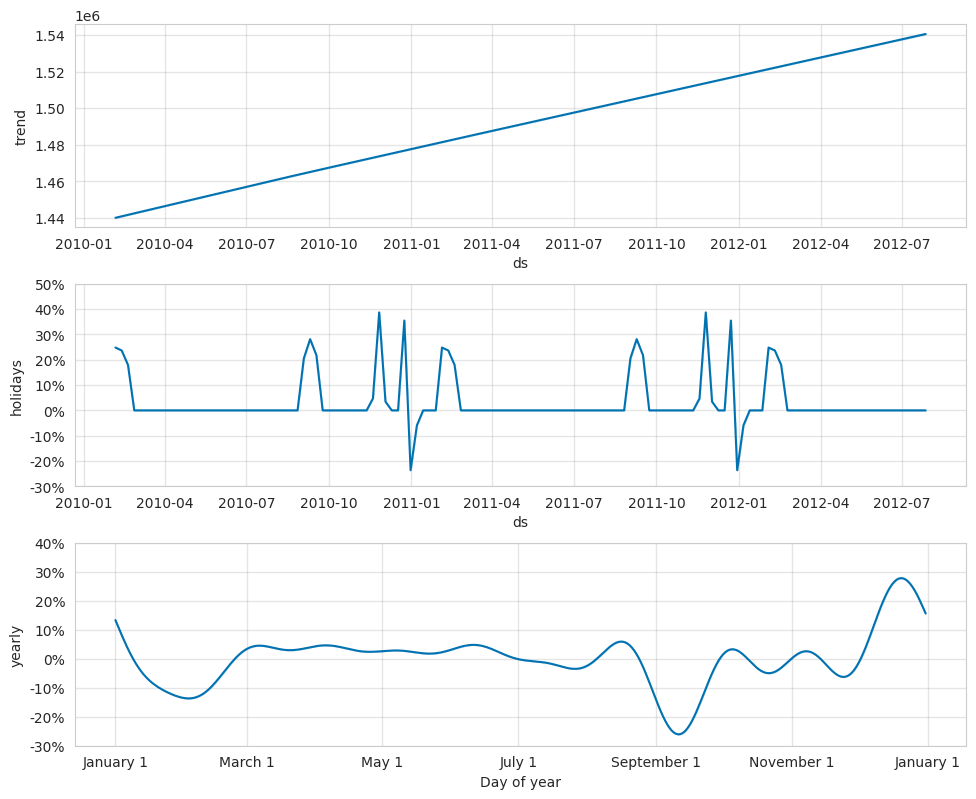

In [33]:
dfp = pd.DataFrame({"ds": totals_tr.index, "y": totals_tr[1].values})
m1 = Prophet(changepoint_prior_scale=best_kw.get("cps", 0.05),
             seasonality_mode=best_kw.get("mode", "additive"),
             yearly_seasonality=best_kw.get("yearly_order", 10),
             weekly_seasonality=False, daily_seasonality=False,
             holidays=best_kw.get("holidays"))
m1.fit(dfp)
fut = m1.make_future_dataframe(periods=39, freq="7D")
fc1 = m1.predict(fut)
fig = m1.plot_components(fc1)
fig.set_size_inches(10, 8)
plt.savefig("pictures/prophet_components.png", dpi=120); plt.show()

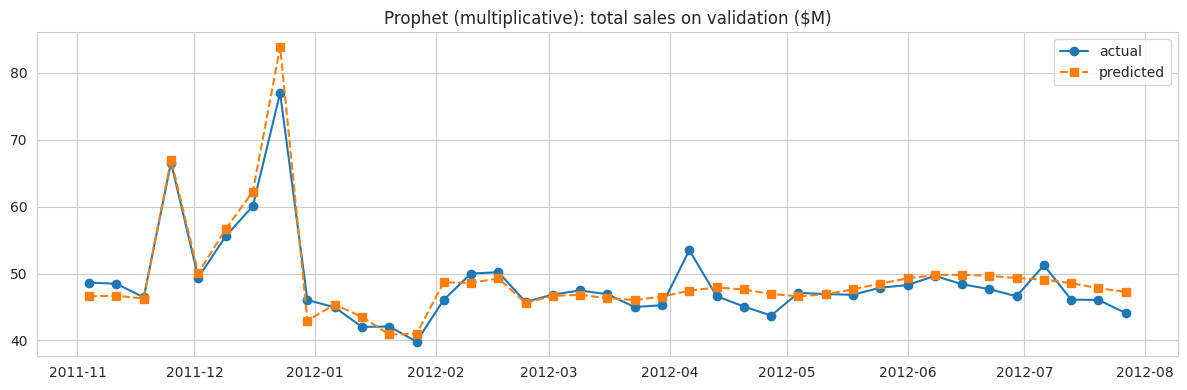

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))
a = val_part.groupby("Date").Weekly_Sales.sum() / 1e6
p = pd.Series(best_val_pred, index=val_part.index).groupby(val_part.Date).sum() / 1e6
ax.plot(a.index, a.values, "o-", label="actual")
ax.plot(p.index, p.values, "s--", label="predicted")
ax.set_title(f"{ARCH} ({best_name}): total sales on validation ($M)")
ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_total.png", dpi=120); plt.show()

Final pipeline + submission

In [35]:
from models import StoreShareForecastPipeline
REGISTER_AS_BEST = False

shares_woy_full, shares_ov_full = prep.build_shares(train_raw)
GLOBAL_MED_FULL = float(train_raw.Weekly_Sales.median())
store_fc_full = store_level_forecast(totals_full, test_dates, **best_kw)
wrapper = StoreShareForecastPipeline(store_fc_full, shares_woy_full,
                                     shares_ov_full, GLOBAL_MED_FULL)
test_pred = wrapper.predict(None, test_raw[["Store", "Dept", "Date"]])
assert len(test_pred) == len(test_raw) and np.isfinite(test_pred).all()

with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({"config": best_name, "strategy": "store-level + dept-share"})
    mlflow.log_metric("val_wmae", results[best_name])
    if os.path.exists(f"pictures/{ARCH.lower()}_val_total.png"):
        mlflow.log_artifact(f"pictures/{ARCH.lower()}_val_total.png")
    mlflow.pyfunc.log_model(
        "model", python_model=wrapper, code_paths=CODE_PATHS,
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)
    run_id = mlflow.active_run().info.run_id
print("pipeline logged, run_id =", run_id)

sub = ev.make_submission(test_raw, test_pred, f"submission_{ARCH}.csv")
print("saved:", f"submission_{ARCH}.csv")

2026/07/10 23:47:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 23:47:21 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/10 23:47:26 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run Prophet_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7/runs/bb037633953a4e7ea653e5e2f33875ab
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/7
pipeline logged, run_id = bb037633953a4e7ea653e5e2f33875ab
saved: submission_Prophet.csv
